Saving image_ict.jpg to image_ict.jpg


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

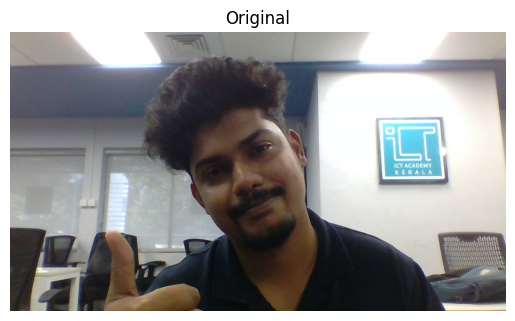

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_name = next(iter(uploaded))
image_bytes = uploaded[image_name]

image = cv2.imdecode(np.frombuffer(image_bytes, np.uint8), cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original")
plt.axis("off")


In [2]:
image = cv2.resize(image, (64, 64))
h, w, c = image.shape


In [3]:
X = image.reshape(-1, 3).astype(np.float32)


In [4]:
def two_color_segmentation(labels):
    unique, counts = np.unique(labels, return_counts=True)

    white_cluster = unique[np.argmax(counts)]

    output = np.zeros((h * w, 3), dtype=np.uint8)
    output[labels == white_cluster] = [255, 255, 255]

    return output.reshape(h, w, 3)


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels_km = kmeans.fit_predict(X)

img_km = two_color_segmentation(labels_km)


In [6]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_agg = agg.fit_predict(X)

img_agg = two_color_segmentation(labels_agg)


In [7]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=8, min_samples=10)
labels_db = db.fit_predict(X)

labels_db[labels_db == -1] = 1

img_db = two_color_segmentation(labels_db)


In [8]:
from scipy.spatial.distance import cdist

def custom_agglomerative(X, n_clusters=2):
    clusters = [[i] for i in range(len(X))]
    centroids = X.copy()

    while len(clusters) > n_clusters:
        dist = cdist(centroids, centroids)
        np.fill_diagonal(dist, np.inf)

        i, j = np.unravel_index(np.argmin(dist), dist.shape)

        clusters[i].extend(clusters[j])
        clusters.pop(j)

        centroids[i] = np.mean(X[clusters[i]], axis=0)
        centroids = np.delete(centroids, j, axis=0)

    labels = np.zeros(len(X), dtype=int)
    for idx, cluster in enumerate(clusters):
        for p in cluster:
            labels[p] = idx

    return labels


In [9]:
labels_cagg = custom_agglomerative(X)

img_cagg = two_color_segmentation(labels_cagg)


In [10]:
def custom_dbscan(X, eps=8, min_samples=10):
    n = len(X)
    labels = np.full(n, -1)
    visited = np.zeros(n, dtype=bool)
    cluster_id = 0

    def region_query(i):
        return np.where(np.linalg.norm(X - X[i], axis=1) <= eps)[0]

    for i in range(n):
        if visited[i]:
            continue

        visited[i] = True
        neighbors = region_query(i)

        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            labels[i] = cluster_id
            queue = list(neighbors)

            while queue:
                j = queue.pop(0)
                if not visited[j]:
                    visited[j] = True
                    new_neighbors = region_query(j)
                    if len(new_neighbors) >= min_samples:
                        queue.extend(new_neighbors)
                if labels[j] == -1:
                    labels[j] = cluster_id

            cluster_id += 1

    return labels


In [11]:
labels_cdb = custom_dbscan(X)

labels_cdb[labels_cdb == -1] = 1

img_cdb = two_color_segmentation(labels_cdb)


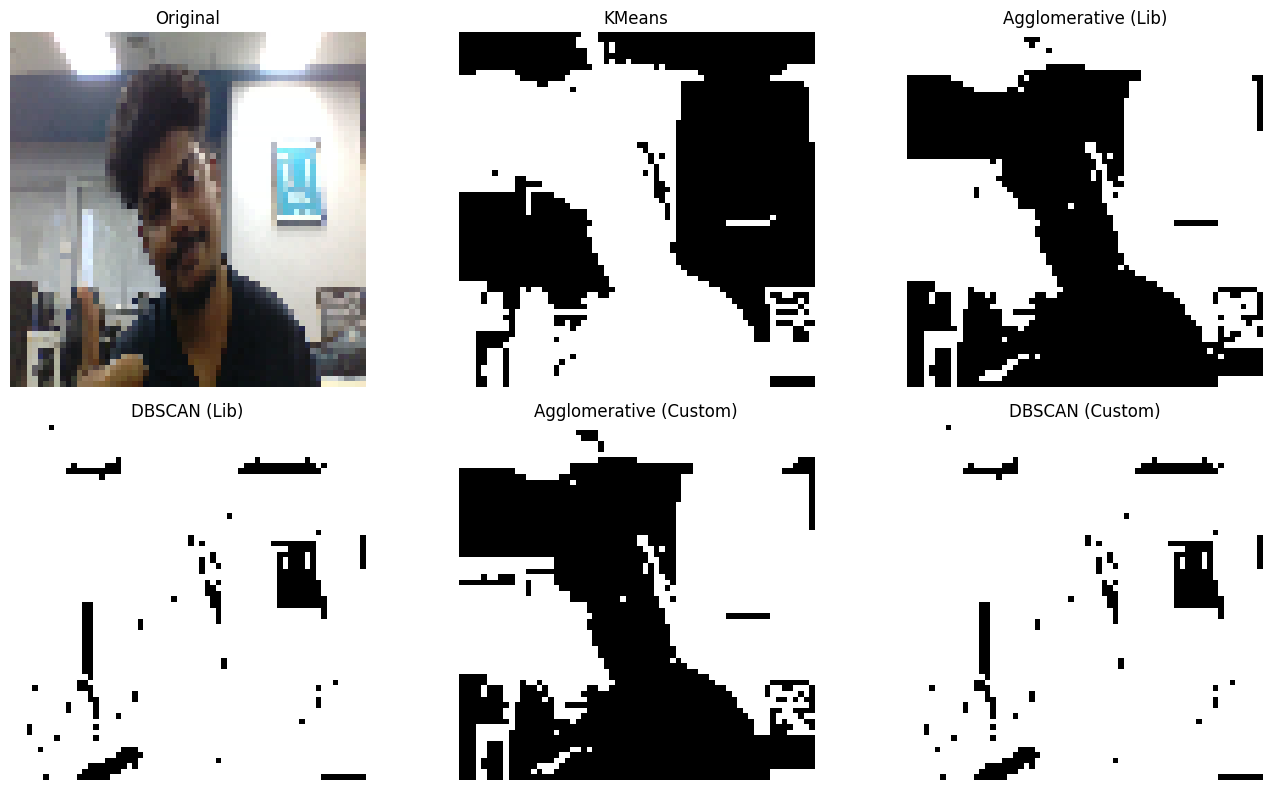

In [12]:
titles = [
    "Original",
    "KMeans",
    "Agglomerative (Lib)",
    "DBSCAN (Lib)",
    "Agglomerative (Custom)",
    "DBSCAN (Custom)"
]

images = [
    image,
    img_km,
    img_agg,
    img_db,
    img_cagg,
    img_cdb
]

plt.figure(figsize=(14, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
